# Кластерный анализ


### Следующий код выполняет три основных шага.
    1. Рассчитывает расстояние до ближайшего соседа между всеми событиями в каталоге.
    2. Разделяет каталог сейсмичности на семейства и независимые фоновые события на основе порогового значения ближайшего соседа.
    3. Подсчитывает количество афтершоков для каждого семейства и строит график зависимости количества афтершоков от магнитуды главного толчка.

### 0: Карта сейсмичности
Загрузка каталога сейсмичности и построение карты с помощью Basemap (этот шаг можно пропустить, если модуль базовой карты mpl не установлен)

In [56]:
# указать файл данных, время и диапазон величин
dir_in = '../data'
# этот файл создается с помощью: 1_create_mat_eqCat_file.ipynb
file_in = 'NEIC_Global_Tohoku_2011.mat'
# completeness magntiude = Mmin, and Mmax (which does not need to be specified)
Mmin, Mmax = 3, None
tmin, tmax = 1900, 2025


In [57]:
#------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os
import scipy.io

#------------------------------my modules-------------------------------------- 
# EqCat is a Python object that is used for catlog processing
from src.EqCat import EqCat
from src import clustering
eqCat = EqCat()
#=================================2==============================================
#                            load data, select events
#================================================================================
eqCat.loadMatBin(f"{dir_in}/{file_in}")
print('Всего событий —', eqCat.size())
eqCat.selectEvents(Mmin, Mmax, 'Mag')
eqCat.selectEvents(tmin, tmax, 'Time')
print('Всего событий после фитрации по магнпитуде и времени —', eqCat.size())

Всего событий — 1926
Всего событий после фитрации по магнпитуде и времени — 1926


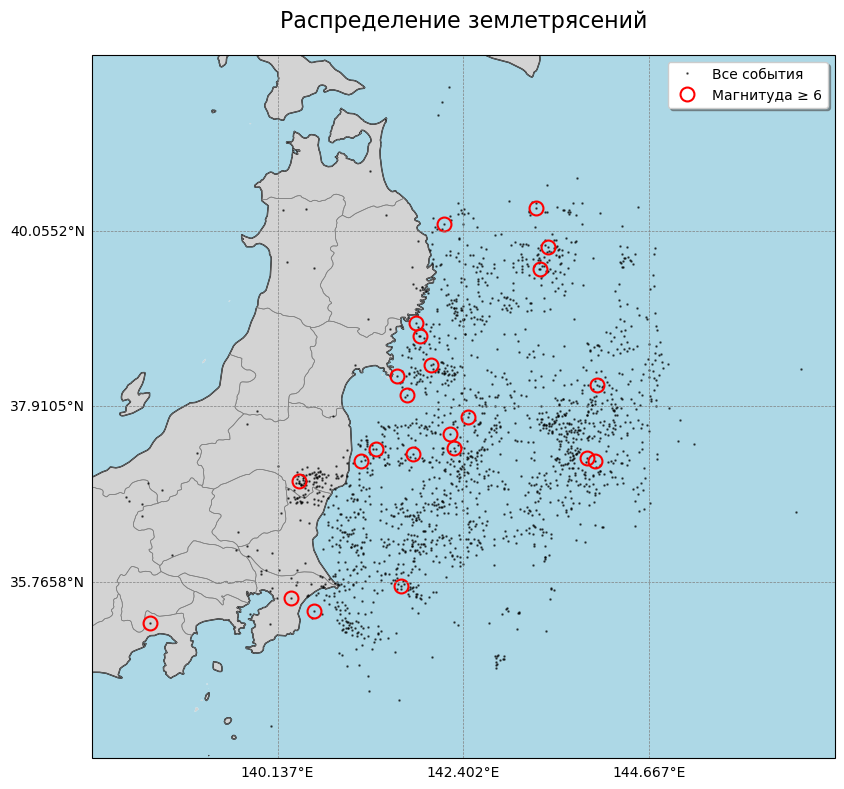

In [58]:
# Проверяем, что данные в eqCat существуют
if hasattr(eqCat, 'data') and all(key in eqCat.data for key in ['Lon', 'Lat', 'Mag']):
    # Определяем границы карты на основе данных
    projection = ccrs.PlateCarree()
    xmin, xmax = eqCat.data['Lon'].min(), eqCat.data['Lon'].max()
    ymin, ymax = eqCat.data['Lat'].min(), eqCat.data['Lat'].max()

    # Добавляем отступы для лучшего отображения
    margin_x = (xmax - xmin) * 0.05
    margin_y = (ymax - ymin) * 0.05
    xmin, xmax = xmin - margin_x, xmax + margin_x
    ymin, ymax = ymin - margin_y, ymax + margin_y

    # Настраиваем фигуру и оси с проекцией PlateCarree
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=projection)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=projection)

    # Добавляем элементы карты
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')

    # Рисуем все события как тонкие чёрные точки
    ax.plot(eqCat.data['Lon'], eqCat.data['Lat'], 'ko', markersize=0.8, alpha=0.6, label='Все события', transform=projection)

    # Выделяем события с магнитудой >= 6 красными окружностями
    sel6 = eqCat.data['Mag'] >= 6
    ax.plot(eqCat.data['Lon'][sel6], eqCat.data['Lat'][sel6], 'ro', markersize=10, markeredgewidth=1.5, mfc='none', label='Магнитуда ≥ 6', transform=projection)

    # Добавляем меридианы и параллели
    meridians = np.linspace(xmin, xmax, 5)
    parallels = np.linspace(ymin, ymax, 5)

    gl = ax.gridlines(
        xlocs=meridians, ylocs=parallels, 
        draw_labels={'bottom': 'x', 'left': 'y'},  # Метки только снизу (x) и слева (y)
        linewidth=0.5, color='gray', linestyle='--'
    )

    # Настраиваем стиль меток
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    # Добавляем заголовок и легенду
    plt.title('Распределение землетрясений', fontsize=16, pad=20)
    plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

    # Отображаем график
    plt.tight_layout()
    plt.show()
else:
    print("Не удалось отобразить график: данные в eqCat.data отсутствуют или неполные.")

### 1: Вычисление расстояний до ближайших соседей

Диапазон глубин: от 0.7  до  131.6
Сохранение файла: data/NEIC_Global_Tohoku_2011_NND_Mc_3.0.mat
Загружаем eta_0 из файла
eta_0 = -9.232


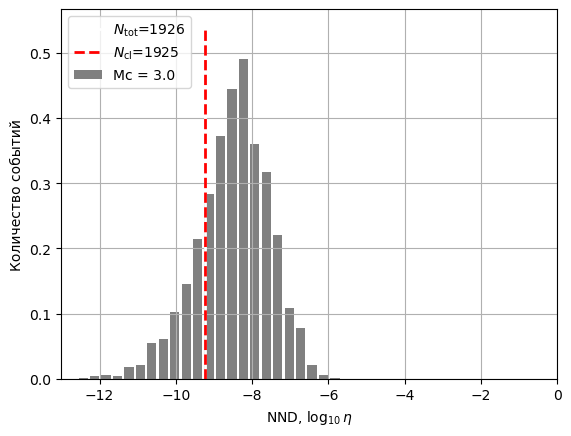

In [ ]:
# Установка параметров
dPar = {
    'D': 1.6,                 # TODO: заменить на реальные значения, полученные из анализа
    'b': 1.3333398574492394,  # b-значение, вычисляется с помощью специального инструмента
    'Mc': Mmin,               # пороговая магнитуда (минимальная магнитуда, выше которой данные полны)
    'eta_binsize': 0.3,       # размер ячейки гистограммы по логарифмической шкале расстояний
    'xmin': -13,              # минимальное значение по оси X (логарифм расстояния)
    'xmax': 0                 # максимальное значение по оси X
}

#================================================================================
#                   Подготовка данных
#================================================================================
# Добавляем глубину как координату Z
eqCat.data['Z'] = eqCat.data['Depth']
print('Диапазон глубин: от', eqCat.data['Z'].min(), ' до ', eqCat.data['Z'].max())

#==================================2=============================================
#        Вычисление расстояний в пространстве-времени-магнитуде (NND, ближайший сосед)
#================================================================================
# Вычисляем расстояния до ближайшего соседа (NND) в масштабированном пространстве
dNND = clustering.NND_eta(eqCat, dPar, correct_co_located=True, verbose=True)

# Построение гистограммы логарифмов расстояний до ближайшего соседа
aBins = np.arange(-13, 1, dPar['eta_binsize'], dtype=float)  # создание массива границ ячеек
aHist, aBins = np.histogram(np.log10(dNND['aNND'][dNND['aNND'] > 0]), aBins)  # гистограмма

# Центрируем ячейки (берём середину интервала)
aBins = aBins[:-1] + dPar['eta_binsize'] * 0.5

# Корректируем гистограмму на размер ячейки (чтобы получить плотность)
aHist = aHist / dPar['eta_binsize']

# Нормируем на общее количество событий → получаем оценку плотности вероятности (PDF)
aHist /= eqCat.size()

#=================================3==============================================
#                            Сохранение результатов
#================================================================================
# Сохраняем данные в формат .mat (MATLAB)
NND_file = f"data/{file_in.split('.')[0]}_NND_Mc_{dPar['Mc']:.1f}.mat"
print('Сохранение файла:', NND_file)

# Сохраняем словарь dNND (включая расстояния до соседей) в .mat-файл с сжатием
scipy.io.savemat(NND_file, dNND, do_compression=True)

#=================================4==============================================
#                          Построение гистограммы
#================================================================================
# Загрузка значения eta_0 (характерное расстояние, связанное с кластеризацией)
eta_0_file = f"data/{file_in}_Mc_{dPar['Mc']:.1f}_eta_0.txt"

if os.path.isfile(eta_0_file):
    print('Загружаем eta_0 из файла')
    f_eta_0 = np.loadtxt(eta_0_file, dtype=float)  # читаем значение eta_0
    print('eta_0 =', f_eta_0)
else:
    # Если файл не найден — используем значение по умолчанию
    f_eta_0 = -5
    print('Файл с eta_0 не найден:', eta_0_file, '— используем значение по умолчанию:', f_eta_0)

# Создаём график
fig, ax = plt.subplots()

# Строим гистограмму как столбчатую диаграмму
ax.bar(aBins, aHist,
       width=0.8 * dPar['eta_binsize'],  # ширина столбцов
       align='edge',                     # выравнивание по краю
       color='.5',                       # серый цвет
       label='Mc = %.1f' % dPar['Mc'])   # подпись: пороговая магнитуда

# Вертикальная белая линия — общее количество событий (N_tot)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'w-', lw=2,
        label=r'$N_\mathrm{tot}$=%i' % eqCat.size())

# Вертикальная красная пунктирная линия — количество кластерных событий (N_cl)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'r--', lw=2,
        label=r'$N_\mathrm{cl}$=%i' % dNND['aNND'][dNND['aNND'] < 1e-5].shape[0])

# Размещаем легенду в верхнем левом углу
ax.legend(loc='upper left')

# Подписи осей
ax.set_xlabel(r'NND, $\log_{10} \eta$')  # NND — расстояние до ближайшего соседа
ax.set_ylabel('Количество событий')

# Включаем сетку
ax.grid(True)

# Устанавливаем пределы по оси X
ax.set_xlim(dPar['xmin'], dPar['xmax'])

# Отображаем график
plt.show()

На рисунке выше показана гистограмма ближайших расстояний между исходными землетрясениями в каталоге (пространство-время-магнитуда).

Стоит обратить внимание на то, что в типичном каталоге землетрясений возникают два различных режима: кластерный режим (слева) и фоновый режим (справа). Первый режим представляет собой кластеризацию типа Омори (обычно «ближе»), а второй — фоновый пуассоновский процесс. Землетрясения в фоновом режиме — это землетрясения, которые, как можно наблюдать, не вызваны предыдущим землетрясением. $\eta_0$ — это пороговое значение между этими двумя режимами. На практике это приведёт к удалению всех связей между землетрясениями, превышающими это пороговое значение, и формированию отдельных кластеров землетрясений.

Для быстрого анализа можно просто выбрать значение, разделяющее эти режимы. Меньшие значения приведут к меньшим кластерам, большие — к более обширным кластерам, но могут включать фоновую сейсмичность.

### 2: Отделение кластеров от независимого фона и составление семейств событий

In [ ]:
dPar['eta_0'] = f_eta_0
print('Порог сходства', dPar['eta_0'])

порог сходства -9.232


In [61]:
clust_file = file_in.replace('all.mat', f'Mc_{dPar["Mc"]:.1f}_clusters.mat')
    
dNND['aNND'] = np.log10( dNND['aNND'])
# кластеризация по критериям сходства eta_0
dClust = clustering.compileClust( dNND, f_eta_0, useLargerEvents = False)
#=================================4==========================================================================
#                           сохранение результатов
#============================================================================================================
scipy.io.savemat( os.path.join( dir_in,clust_file), dClust, do_compression=True)


Предполагается, что порог (-9.232) — это МАКСИМУМ, выбираем значения схожести НИЖЕ этого порога
---------compileClust - начальные числа:------
Количество одиночных: 1481
Количество триггерных: 445, 445,Общее количество: 445 1925
Количество ID событий в нескольких кластерах: 0
Начальные одиночные события, ставшие родительскими - удаляем из dClust['0']:  160
---------------Итоговый результат--------------------------
 Общее количество в кластерах: 605, Количество родителей (=количество кластеров): 160,Количество одиночных: 1321, Общее количество потомков (включая дубликаты):  445
Доля триггерных:  0.23 Доля главных толчков:  0.08 Одиночные:  0.69
Общее количество в каталоге:  1926 Триггерные + одиночные 1926


### Создание тестовых графиков для проверки работоспособности.
Первый график даёт приблизительный обзор кластерных и независимых событий в области пространства-времени с изменённым масштабом.

Это обеспечивает визуализацию кластерного поведения, описанного выше. На этот раз в нормализованном пространственном расстоянии ($R_{ij}$) в сравнении с нормализованным временным расстоянием ($T_{ij}$). Где:

$$ R_{ij} = r_{ij}^d\times10^{bM_i/2} $$
$$ T_{ij} = t_{ij}\times10^{bM_i/2} $$

Размер каталога потомков 1925 Размер каталога родителей 1925
check if integral ~1 0.73


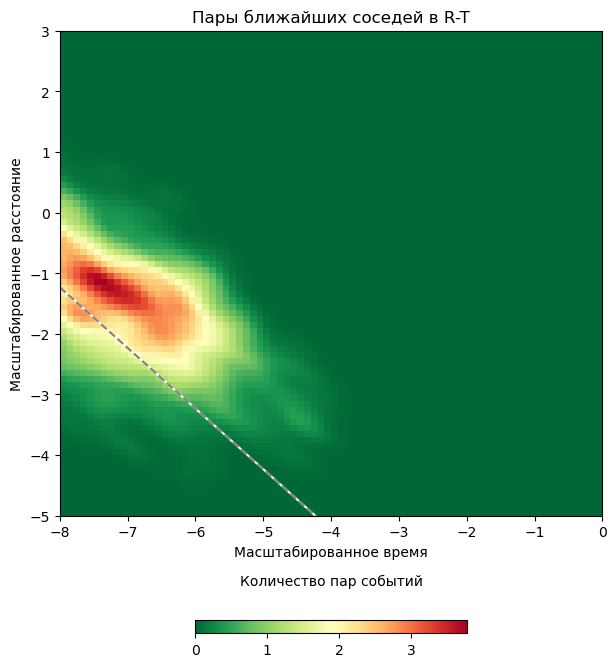

In [ ]:
#=======Плотность пар событий в r-T============================
catChild = EqCat()
catParent = EqCat()
catChild.copy(eqCat)
catParent.copy(eqCat)
catChild.selEventsFromID(dNND['aEqID_c'], repeats=True)
catParent.selEventsFromID(dNND['aEqID_p'], repeats=True)
print('Размер каталога потомков', catChild.size())  
print('Размер каталога родителей', catParent.size())  
#Вычисляем масштабированные межсобытийные времена и расстояния
a_R, a_T = clustering.rescaled_t_r(catChild, catParent, dPar)
# Построение графика плотности пар событий 
fig = clustering.plot_R_T( a_T, a_R, f_eta_0)


1. **Оси**:
   - **X-ось (Rescaled Time)**: Масштабированное время (log10(a_T)), где `a_T` — это разница во времени между родительским и дочерним событиями, скорректированная с учётом магнитуды и параметров каталога (b-значение и фрактальная размерность D). Это отражает, насколько быстро происходят афтершоки относительно основного толчка.
   - **Y-ось (Rescaled Distance)**: Масштабированное расстояние (log10(a_R)), где `a_R` — это пространственное расстояние между событиями, также скорректированное с учётом параметров (обычно в километрах, преобразованное через фрактальную размерность).

2. **Цветовая карта (Density Plot)**:
   - График использует двумерную плотность событий (`normZZ`), вычисленную функцией `data_utils.density_2D`. Чем ярче цвет (например, зелёный или жёлтый по схеме `RdYlGn_r`), тем выше концентрация пар событий в данной области.
   - `normZZ` нормализуется на общее количество событий и размер ячеек (`binx * biny * eqCatMc.size()`), чтобы отразить количество пар событий на единицу площади.

3. **Линия разделения (eta_0)**:
   - На графике рисуются две линии:
     - Твёрдая белая линия (`'-', lw=1.5, color='w'`) и пунктирная серая линия (`'--', lw=1.5, color='.5'`) на уровне `f_eta_0`.
     - Эти линии представляют границу между кластерными (ниже порога) и фоновыми (выше порога) событиями. События ниже этой линии считаются связанными (например, афтершоками), а выше — независимыми.

- **Распределение кластеров**: График показывает, как пары событий группируются во времени и пространстве после масштабирования. Кластерные события (афтершоки) обычно сосредоточены в нижней левой части (близкие времена и расстояния), тогда как фоновые события распределены более равномерно.
- **Порог eta_0**: Значение `eta_0` используется для разделения. Если логарифм масштабированного времени минус логарифм масштабированного расстояния меньше `eta_0`, событие классифицируется как часть кластера.
- **Интерпретация плотности**: Высокая плотность (яркие области) указывает на регионы, где афтершоки наиболее вероятны (например, сразу после главного толчка на небольших расстояниях).

Теперь давайте также рассмотрим различные семьи и то, как связаны между собой отдельные события.

Text(0, 0.5, 'Latitude')

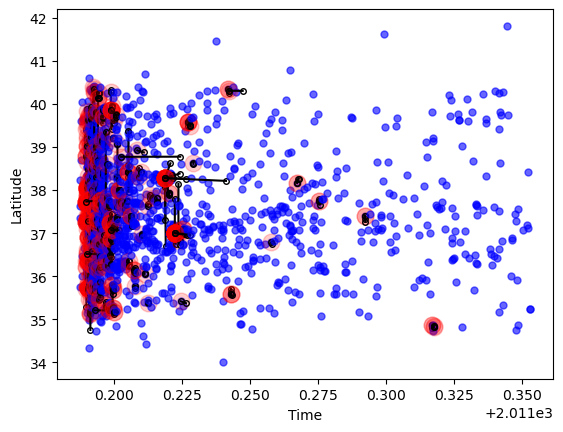

In [63]:
#==================================4=============================================
#                          spanning tree
#================================================================================
plt.figure( 1)
ax = plt.subplot(111)  
for iEv in range( catParent.size()):
    print( f"MS-ID, {int(catParent.data['N'][iEv]):d}, t-Par: {catParent.data['Time'][iEv]:.5f},'t-child', {eqCat.data['Time'][iEv]:.5f}", end= "\r")

    if dNND['aNND'][iEv] < dPar['eta_0']:#triggered cluster
        ax.plot( [catParent.data['Time'][iEv]], [catParent.data['Lat'][iEv]], 'ro', ms = 12, alpha = .2)
        ax.plot( [catParent.data['Time'][iEv],catChild.data['Time'][iEv]],
                  [catParent.data['Lat'][iEv], catChild.data['Lat'][iEv]], 'k-', marker = 'o', ms = 4, mew =1, mfc = 'none')
    else: # independent events
        ax.plot( [catChild.data['Time'][iEv]], [catChild.data['Lat'][iEv]], 'bo', ms = 5, alpha = .6)
ax.set_xlabel('Time')
ax.set_ylabel('Latitude')

Синие точки на представленном выше графике представляют собой независимые фоновые события. Это означает, что их ближайший сосед находится за пределами выбранного (или рассчитанного) значения eta_0.

Красные и чёрные круги — это кластерные события, соединённые чёрными линиями.
Чем темнее красный цвет, тем больше событий связано с этим родителем.
Чёрные круги — это последнее поколение в серии триггеров, т.е. афтершоки, которые сами по себе не вызывают афтершоков.

### 3: Подсчет афтершоков и построение графика зависимости производительности атершоков

In [64]:
#=================================1==============================================
#                            Загрузка данных, выбор событий
#================================================================================
N_tot = eqCat.size()
print( 'Общее количество событий', N_tot)
#=================================2==========================================================================
#                     Одиночные события считаются главными толчками с 0 афтершоками
#============================================================================================================
print( 'Общее количество кластеров', len( dClust.keys()), 'Количество фоновых событий', dClust['0'].shape[0])
a_ID_single  = dClust['0']

# ID фоновых событий
a_iSel       = np.zeros( eqCat.size(), dtype = int)
a_mag_single = np.zeros( len( a_ID_single))
a_N_AS_single= np.zeros( len( a_ID_single))
a_N_FS_single= np.zeros( len( a_ID_single))
for i in range( a_ID_single.shape[0]):
    # ID события может встречаться в каталоге несколько раз
    sel_ev          = eqCat.data['N'] == a_ID_single[i]
    a_mag_single[i] = eqCat.data['Mag'][sel_ev][0]
    a_iSel[sel_ev] = 1 # catalog.data['N'][catalog.data['N']==aEqID[i]][0]
    if sel_ev.sum() != 1:
        error_str = 'Найдено более одного события', eqCat.data['N'][sel_ev]
        raise( ValueError( error_str))
### удаляем одиночные события из каталога
eqCat.selDicAll( np.logical_not(a_iSel))
print( 'Оставшиеся события', eqCat.size(), 'Фоновые события', len( a_mag_single))
dClust.pop('0') # удаляем одиночные события

Общее количество событий 1926
Общее количество кластеров 161 Количество фоновых событий 1321
Оставшиеся события 605 Фоновые события 1321


array([189972., 189973., 189974., ..., 193194., 193199., 193203.],
      shape=(1321,))

In [65]:
#=================================2==========================================================================
#                   Получение магнитуд главных толчков с афтершоками, подсчёт афтершоков
#============================================================================================================
a_N_FS    = np.zeros( len( dClust.keys()), dtype = int)
a_N_AS    = np.zeros( len( dClust.keys()), dtype = int)
a_MS_mag  = np.zeros( len( dClust.keys()))
a_MS_ID   = np.zeros( len( dClust.keys()), dtype = int)
iCl = 0
for sCl in dClust.keys():
    aEqID = dClust[sCl]# np.unique( dClust[sCl].flatten()) уникальность больше не требуется, createCluster исправлен
    print( 'Кластер: ', iCl+1,'из: ', len( dClust.keys()), 'Количество событий в кластере.', 
          len( aEqID), len( np.unique( dClust[sCl])), end="\r")
    # находим магнитуду главного толчка и магнитуду всей семьи
    atmp_MAG = np.zeros( len( aEqID))
    atmp_Time= np.zeros( len( aEqID))
    a_iSel   = np.zeros( eqCat.size(), dtype = int)
    # для каждой семьи находим: магнитуду события и время возникновения
    for iM in range( len( aEqID)):
        sel_ev        = eqCat.data['N'] == aEqID[iM]
        if sel_ev.sum() != 1:
            error_str = 'Найдено более одного или ни одного события', eqCat.data['N'][sel_ev], aEqID[iM]
            raise(  ValueError, error_str)
        atmp_MAG[iM]  = eqCat.data['Mag'][sel_ev][0]
        atmp_Time[iM] = eqCat.data['Time'][sel_ev][0]
        a_iSel[sel_ev] = 1
    # удаляем события из каталога
    #catalog.selDicAll( np.logical_not(a_iSel))
    #----------------------------главный толчок-------------------------------------------------- 
    selMS     = atmp_MAG == atmp_MAG.max()
    f_tMS     = atmp_Time[selMS][0]
    i_ID_MS   = aEqID[selMS]

    #print( 'tMS', tMS, v_currEqID.shape[0], 'MAG', curr_cat.data['MAG'][selMS][0]
    #----------------------------афтершоки-------------------------------------------------- 
    selAS     = atmp_Time > f_tMS
    selFS     = atmp_Time < f_tMS
    #print( 'Количество афтершоков', selAS.sum()
    # сохраняем количество афтершоков для каждой магнитуды главного толчка
    a_MS_mag[iCl] = atmp_MAG[selMS][0]#, dPar['magRound'])
    a_N_AS[iCl]   = selAS.sum()
    a_N_FS[iCl]   = selFS.sum()
    a_MS_ID[iCl]  = int( i_ID_MS[0])
    iCl += 1

#=================================3==========================================================================
#                  Сравнение главных толчков + одиночных + форшоков + афтершоков с исходным количеством событий в каталоге
#============================================================================================================
# объединяем одиночные события без афтершоков с главными толчками, у которых есть афтершоки
a_N_FS    = np.append( a_N_FS, a_N_FS_single)
a_N_AS    = np.append( a_N_AS, a_N_AS_single)
a_MS_mag  = np.append( a_MS_mag, a_mag_single)
a_MS_ID   = np.append( a_MS_ID, a_ID_single)
print( 'Всего событий в каталоге', N_tot,'Всего событий в семьях',a_N_FS.sum() + a_N_AS.sum() + a_MS_mag.shape[0])
#print( 'Фоновые события', a_mag_single.shape[0], 'Форшоки', a_N_FS_single.sum(), 'Афтершоки', a_N_AS_single.sum(), 'Главные толчки (MS+BG)', a_MS_mag.shape[0]

#=================================4==========================================================================
#                    Сохранение в текстовый файл ASCII
#============================================================================================================
file_out = '%s/%s_Nas_MS_Mc_%.1f.txt'%(dir_in, file_in.split('.')[0], dPar['Mc'])#, dPar['magRound'])
m_N_as   = np.array([a_MS_mag, a_N_AS, a_N_FS, a_MS_ID])
np.savetxt(f"data/{file_out}", m_N_as.T, fmt='%10.3f%10i%10i%14i',
            header = 'MAG          N-AS          N-FS        MS-ID; note N_AS=0 highlights singles or FS only')

Всего событий в каталоге 1926 Всего событий в семьях 1926.0


Два числа выше должны совпадать, в противном случае, возможно, придется перезапустить код с самого начала.

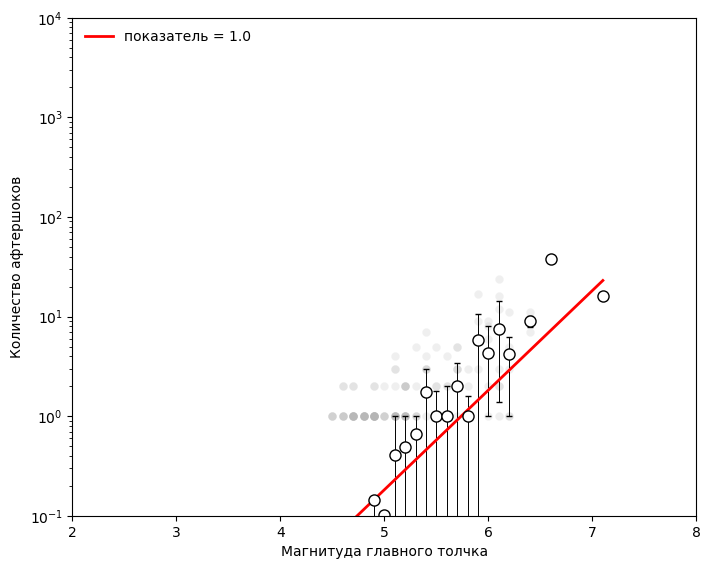

In [66]:
dPar['magRound'] = 1 # биннинг
#=================построение графиков==============
dPar['alpha']    =  1.0 # показатель степени закона
dPar['xmin']     =  2  
dPar['xmax']     =  8
dPar['ymin']     = 0.1  
dPar['ymax']     = 1e4

#=================================2==========================================================================
#                           Подсчёт среднего количества афтершоков для магнитуды главного толчка
#============================================================================================================
aMag_round= np.around( m_N_as[0], dPar['magRound'])
aMag_bin  = np.array( sorted(np.unique( aMag_round)))
aAveNo_AS = np.ones( len( aMag_bin))*np.nan
aNo_Fam   = np.zeros( len( aMag_bin)) # общее количество семей в бине магнитуды
aNo_AS20  = np.zeros( len( aMag_bin))
aNo_AS80  = np.zeros( len( aMag_bin))

i = 0
for curr_mag in aMag_bin:
    selMag       = curr_mag == aMag_round
    aAveNo_AS[i] = m_N_as[1][selMag].mean()
    if selMag.sum() > 0:
        aNo_AS20[i]  = np.percentile( m_N_as[1][selMag], 20)
        aNo_AS80[i]  = np.percentile( m_N_as[1][selMag], 80)
    aNo_Fam[i]   = selMag.sum()
    print( curr_mag, 'Среднее N-АФТЕРШОКОВ', round(aAveNo_AS[i],2),  aNo_AS20[i],aNo_AS80[i], 'Количество семей', aNo_Fam[i],end="\r")

    i += 1

#=================================3==========================================================================
#                           Построение закона продуктивности
#============================================================================================================
plt.figure(1, figsize=(8,6))
ax = plt.axes([.14,.12,.78,.83])#pPlot.createFigureSquare(1)
ax.semilogy( m_N_as[0],   m_N_as[1],     'o',  ms = 6, mew =0, mfc = '.7', alpha = .2 )
yerr_low = np.maximum(0, aAveNo_AS - aNo_AS20)
yerr_high = np.maximum(0, aNo_AS80 - aAveNo_AS)
#ax.errorbar( aMag_bin,  aAveNo_AS, yerr=[np.zeros(aMag_bin.shape[0]), aNo_AS80-aAveNo_AS],
#             fmt = 'o', ecolor = 'k', elinewidth=.7,capsize=2.5, mec = 'k', ms = 8, mew = 1, mfc = 'w')
#ax.errorbar( aMag_bin,  aAveNo_AS, yerr=[aAveNo_AS-aNo_AS20, aNo_AS80-aAveNo_AS],
#             fmt = 'o', ecolor = 'k', elinewidth=.7,capsize=2.5, mec = 'k', ms = 8, mew = 1, mfc = 'w')
ax.errorbar(aMag_bin, aAveNo_AS, yerr=[yerr_low, yerr_high],
            fmt='o', ecolor='k', elinewidth=.7, capsize=2.5, mec='k', ms=8, mew=1, mfc='w')

#-------------------------экспоненциальная оценка-----------------------------------------------------
mag_fit    = aMag_bin[min(4, len(aMag_bin)-1)] # принудительная подгонка через эту точку
f_no_AS_pl = aAveNo_AS[aMag_bin == mag_fit]
preFac     = np.log10( f_no_AS_pl) - dPar['alpha']*mag_fit
a_N_hat    = 10**( dPar['alpha']*aMag_bin + preFac)
ax.semilogy( aMag_bin, a_N_hat, 'w-')
ax.semilogy( aMag_bin, a_N_hat, '-', color = 'r', lw = 2, label = 'показатель = %.1f'%( np.round( dPar['alpha'],1)))

#-------------------------------подписи, пределы и т.д.-----------------------------------------------
ax.set_xlim( dPar['xmin'], dPar['xmax'])
ax.set_ylim( dPar['ymin'], dPar['ymax'])
ax.set_xlabel( 'Магнитуда главного толчка')
ax.set_ylabel( 'Количество афтершоков')
ax.legend( loc = 'upper left', frameon = False);

Ошибка: Размер dNND['aNND'] (1925) не соответствует размеру каталога (605).
Синхронизируем dNND с текущим каталогом...
Предупреждение: Найдено 605 неположительных значений в dNND['aNND']. Игнорируем их для log10.


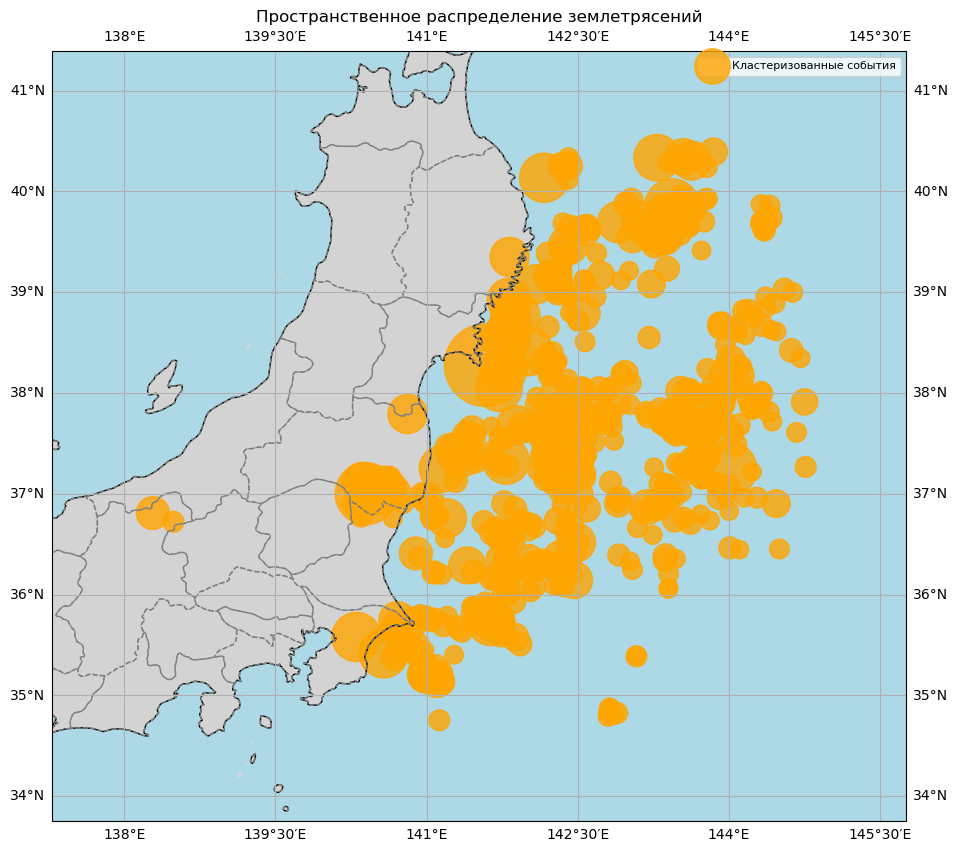

In [67]:
#=================================4==========================================================================
#                           Визуализация кластеров на географической карте
#============================================================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    print("Ошибка: Cartopy не установлен. Установите его с помощью 'pip install cartopy' или 'conda install cartopy'.")
    raise

# Предполагается, что dNND — результат функции NND_eta, а dClust — результат separateFamilies
# Если они не определены, нужно выполнить NND_eta и separateFamilies
# Пример:
# from clustering import NND_eta, separateFamilies
# dConst = {'Mc': Mmin, 'b': 1.0, 'D': 1.6}
# dNND = NND_eta(eqCat, dConst, verbose=True)
# dClust = separateFamilies(dNND, eta_0=-4.5)

# Проверяем наличие dNND
try:
    dNND
except NameError:
    print("Ошибка: dNND не определён. Выполните NND_eta перед визуализацией.")
    raise

# Синхронизируем dNND с текущим каталогом
if len(dNND['aNND']) != len(eqCat.data['Lon']):
    print(f"Ошибка: Размер dNND['aNND'] ({len(dNND['aNND'])}) не соответствует размеру каталога ({len(eqCat.data['Lon'])}).")
    print("Синхронизируем dNND с текущим каталогом...")
    sel_valid = np.isin(dNND['aEqID_c'], eqCat.data['N'])
    dNND = {
        'aNND': dNND['aNND'][sel_valid],
        'aEqID_p': dNND['aEqID_p'][sel_valid],
        'aEqID_c': dNND['aEqID_c'][sel_valid],
        'Time': dNND['Time'][sel_valid]
    }

# Проверяем, что размеры совпадают
if len(dNND['aNND']) != len(eqCat.data['Lon']):
    print(f"Ошибка: После синхронизации размер dNND['aNND'] ({len(dNND['aNND'])}) всё ещё не соответствует размеру каталога ({len(eqCat.data['Lon'])}).")
    raise IndexError("Несоответствие размеров данных.")

# Определяем sel_clust: события с log10(aNND) < eta_0 считаются кластеризованными
eta_0 = -4.5  # Настройте порог на основе анализа (например, из plot_R_T)
# Проверяем на неположительные значения в aNND
valid_nnd = dNND['aNND'] > 0
if not valid_nnd.all():
    print(f"Предупреждение: Найдено {np.sum(~valid_nnd)} неположительных значений в dNND['aNND']. Игнорируем их для log10.")
sel_clust = np.zeros_like(dNND['aNND'], dtype=bool)
sel_clust[valid_nnd] = np.log10(dNND['aNND'][valid_nnd]) < eta_0  # Булев массив для кластеризованных событий

# Проверяем наличие dClust
try:
    dClust
except NameError:
    print("Ошибка: dClust не определён. Убедитесь, что separateFamilies выполнена.")
    raise

# Синхронизируем dClust с текущим каталогом
for famID in list(dClust.keys()):
    indices = dClust[famID]
    valid_indices = np.isin(indices, eqCat.data['N'])
    dClust[famID] = indices[valid_indices]
    if len(dClust[famID]) == 0:
        print(f"Предупреждение: Кластер {famID} пуст после синхронизации. Удаляем его.")
        del dClust[famID]

num_clusters = len(dClust)
if num_clusters == 0:
    print("Предупреждение: Нет кластеров для отображения после синхронизации.")

# Создаём фигуру с географической проекцией
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())  # Простая географическая проекция

# Добавляем географические элементы
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')

# Устанавливаем границы карты
lon_min, lon_max = eqCat.data['Lon'].min() - 1, eqCat.data['Lon'].max() + 1
lat_min, lat_max = eqCat.data['Lat'].min() - 1, eqCat.data['Lat'].max() + 1
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Рисуем все кластеризованные события оранжевым цветом
for i, (famID, indices) in enumerate(dClust.items()):
    if len(indices) > 0:
        sel_indices = np.isin(eqCat.data['N'], indices)
        ax.scatter(eqCat.data['Lon'][sel_indices], eqCat.data['Lat'][sel_indices],
                   s=10**(eqCat.data['Mag'][sel_indices]/2),  # Размер маркера зависит от магнитуды
                   c='orange', alpha=0.8, label='Кластеризованные события' if i == 0 else None,
                   transform=ccrs.PlateCarree())

# Устанавливаем подписи
ax.set_title('Пространственное распределение землетрясений')

# Добавляем сетку
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Легенда
ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.show()